# Lab 8 - Segmentação Morfológica *Watershed*

### Tranformada de Distância, e Rotulação (*Label*)

**Aluno(s):** Gabriella Rodrigues, Nayara Amaral, Veronica Isobe \
**Data de publicação:** 28/04/2026 \
**Data de realização dos experimentos:** 28/04/2026

# 1. Introdução
Este relatório apresenta o desenvolvimento e a análise de técnicas de segmentação morfológica de imagens, com foco no algoritmo Watershed. Ao longo do trabalho, são realizados procedimentos experimentais em ambiente Python, utilizando ferramentas como OpenCV, NumPy e Matplotlib. As atividades incluem a aplicação da segmentação em imagens do próprio grupo e de avatares, além da implementação de um sistema em tempo real com uso de webcam, capaz de detectar, segmentar e rotular objetos na imagem.

# 2. Procedimentos experimentais

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from morph import *

In [26]:
img = cv2.imread('foto1.jpg')
img_personagem = cv2.imread('foto_personagem.png')
postura = cv2.imread('postura_incorreta.jpg')

In [27]:
def marker(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # remoção de ruído
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # fundo certo
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # objeto certo
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(
        dist_transform, 0.7 * dist_transform.max(), 255, 0
    )

    # região desconhecida
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # rotulação
    ret, markers = cv2.connectedComponents(sure_fg)

    # ajustar labels
    markers = markers + 1

    # marcar desconhecido como 0
    markers[unknown == 255] = 0

    return markers.astype(np.int32)

In [28]:
def watershed(img):
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    markers = marker(img)
    plt.figure(figsize=(10,6))
    plt.imshow(markers,"gray"),plt.title('markers')
    plt.xticks([]), plt.yticks([])
    plt.show()

2.a Segmentação Morfológica WATERSHED

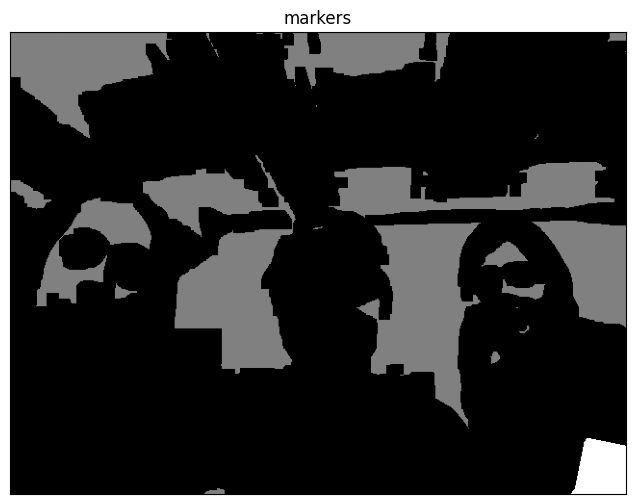

In [29]:
watershed(img)

In [30]:
watershed(img_personagem)

AttributeError: 'NoneType' object has no attribute 'shape'

2.c ELABORAÇÃO DE PROGRAMAS COM A WEBCAM

In [ ]:
filterChoice = 1
limiar = 80

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao acessar webcam")
    exit()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = None
gravando = False
        
contador = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    markers = marker(frame)
    markers_norm = cv2.normalize(markers, None, 0, 255, cv2.NORM_MINMAX)
    frameWithFilter = np.uint8(markers_norm)
    texto = f"Seguimentado"

        
    key = cv2.waitKey(1) & 0xFF

    thresh_bgr = cv2.cvtColor(frameWithFilter, cv2.COLOR_GRAY2BGR)

    combinado = np.hstack((frame, thresh_bgr))
    cv2.putText(combinado, texto, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
    cv2.putText(combinado, "Pressione: w=gravar | +/- limiar | q=sair",
                (10, 460), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)

    cv2.imshow("Original | Limiarizada", combinado)

    if gravando:
        out.write(combinado)

    if key == ord('+'):
        limiar = min(255, limiar + 5)

    if key == ord('-'):
        limiar = max(0, limiar - 5)

    if key == ord('w'):
        gravando = not gravando

        if gravando:
            print("Gravando...")
            out = cv2.VideoWriter(
                "video_demo.avi",
                fourcc,
                20.0,
                (combinado.shape[1], combinado.shape[0])
            )
        else:
            print("Parou gravação")
            out.release()   
    if key == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

2.d Elaborar um programa para aplicar Segmentação Morfológica WATERSHED em
imagens do seu trabalho final

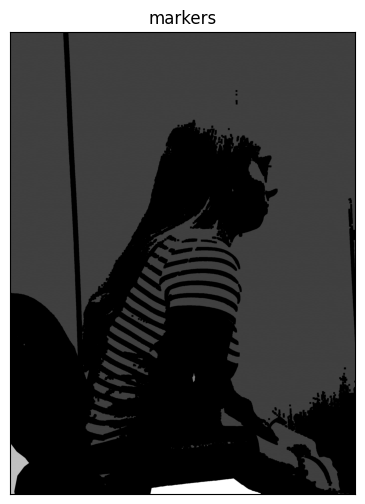

In [ ]:
watershed(postura)

Para o contexto do nosso trabalho ele pode ser usado para isolar a pessoa que está sendo utilizada no experimento do resto da cena

Análise e Discussão dos Resultados

A aplicação do algoritmo Watershed permitiu a segmentação dos objetos presentes nas imagens e no vídeo capturado pela webcam, separando regiões com base em suas características de intensidade e distância. O método demonstrou boa capacidade de identificar contornos e dividir elementos próximos, especialmente quando há contraste suficiente entre objeto e fundo.